# TP : Réseau de neurones avec PyTorch

In [ ]:
# Import 

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import random_split

import helper

import matplotlib.pyplot as plt

# Introduction: Perceptron et MNIST

Vous avez à votre disposition 2 fichiers d’implémentation du (même) perceptron (vu en cours) :
1. perceptron pytorch.py qui utilise uniquement les tenseurs
2. perceptron pytorch data auto layer optim.py qui utilise la plupart des outils de
PyTorch (les dataloaders, la différenciation automatique, les couches et les optimiseurs)

Ce perceptron apprend sur le jeu de données MNIST qui contient des images de chiffres manuscrits.

<img src='img/mnist.png'  width=500px>

>  <span style="color:green">**Exercice**: </span>:

<span style="color:green">- Lire, comprendre, tester ces 2 fichiers.</span>




# TP: MLP et Fashion-MNIST 

L'objectif est de mettre en place différents MLP pour résoudre un problème de classification de vêtements à partir d'images. Le dataset Fashion-MNIST est composé d'images de vêtements en niveaux de gris. Chaque image du dataset est de taille 28x28 pixels. 

<img src='img/fashion-mnist-sprite.png'  width=500px>

Le réseau de neurones doit prendre en entrée une de ses images et prédire quel type de vêtements est dans l'image passée en entrée (parmi 10 classes possibles de vêtements).

### Dataset Fashion-MNIST

Tout d'abord, le dataset Fashion-MNIST est récupéré à partir du package `torchvision`.Le code ci-dessous charge le dataset, puis crée les dataset d'entrainement et de test.

In [23]:
# !pip install torchvision
from torchvision import datasets, transforms

# Une transformation est definie pour normaliser les donness
# La tranasformation est appliqué après le chargement des images, avant de les envoyer au NN
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize([0.5], [0.5]) 
                             ])

# Chargement des donnees d'entrainement
trainset = datasets.FashionMNIST('F_MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Chargement des donnees de test
testset = datasets.FashionMNIST('F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)


Les données d'entrainement sont chargées dans `trainloader` et un itérateur est disponible avec `iter(trainloader)`. 

```python
dataiter = iter(trainloader)
#recuperation d'un batch
images, labels = next(dataiter)
```

Pour boucler sur les données du dataset:

```python
for images, labels in trainloader:
    ## a chaque iteration, recupere un batch d'images dans 'images' et les labels associés
```




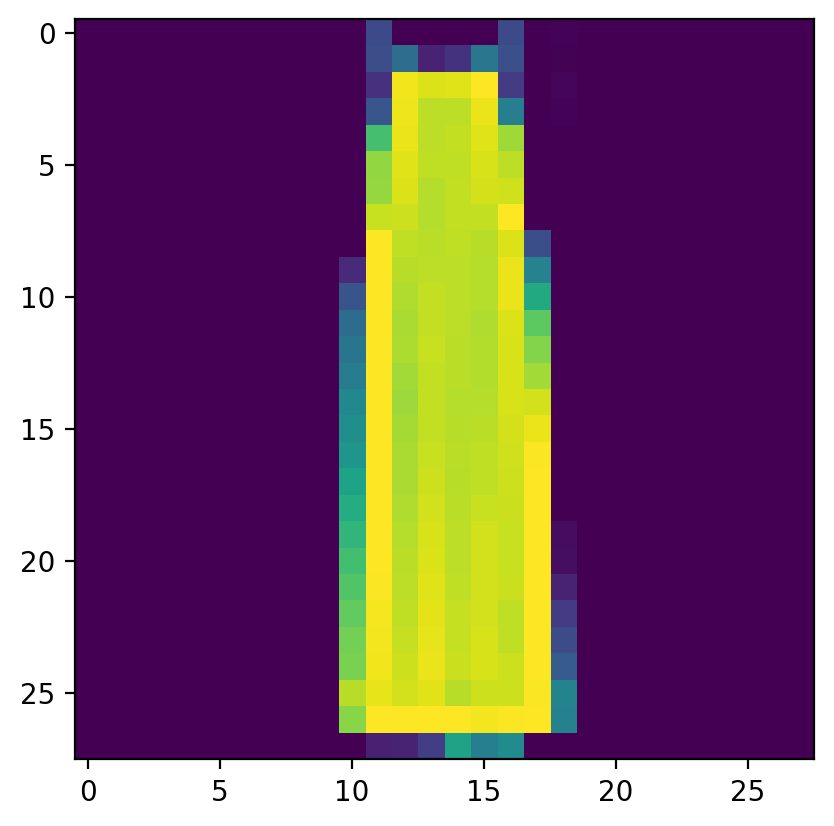

In [24]:
#affichage de la premiere image du batch
dataiter = iter(trainloader)
images, labels = next(dataiter)
plt.imshow(images[0].numpy().squeeze());

#The squeeze() function is used to remove single- dimensional entries from the shape of an array.


>  <span style="color:green">**Exercice**: </span>:

<span style="color:green">-Combien y-a-t'il d'images dans l'ensemble d'entrainement et dans celui de test ?</span>

<span style="color:green">- Afficher le type et la taille (*shape*) d'un batch. A quoi correspond chaque dimension ? </span>

<span style="color:green">- Les labels sont-ils représentés sous forme de vecteurs *one-hot* ?</span>

<span style="color:green">- Combien de batchs y'a-t'il dans l'ensemble d'entrainement et de test  ?</span>



### Construction d'un réseau de neurones avec PyTorch: Exemple

Pour construire un réseau de neurones, nous utilisons le module [torch.nn](https://pytorch.org/docs/stable/nn.html) et héritons de la classe `torch.nn.Module`.

* Dans le constructeur `init`, les paramètres du modèle sont définis. Ces paramètres sont les poids de chaque couche, i.e. des tenseurs sur lesquels une remontée de gradient devra être réalisée lors de l'apprentissage du réseau. Pour cela, on peut utiliser les *layers* de PyTorch. Ainsi, chaque couche du réseau est définie séparément. Pour un réseau *feed-forward* où chaque couche réalise une combinaison linéaire, on utilise le *layer* `nn.Linear(nbx,nby)` où `nbx` est le nombre d'entrées et `nby` le nombre de sorties de la couche. 

* La méthode `forward(x)` réalise la prédiction (*forward pass*) du réseau pour une entrée `x`. Il faut donc réaliser les prédictions de chaque couche du modèle, et les passer aux fonctions d'activation. Pour les fonctions d'activation, le module `torch.nn.functional`  est couramment importé sous le nom `F`. Pour une activation ReLU par exemple, `F.relu(x)` calcule l'activation ReLU pour le tenseur `x`.


Ci-dessous est modélisé un simple perceptron mono-couche en PyTorch:

In [ ]:
class PerceptronMonoCouche(nn.Module):
    def __init__(self):
        super().__init__()
        
        #bonne pratique: nommer vos couches selon leur type, par exemple `fc` pour une couche fully-connected.
        self.fc1 = nn.Linear(3, 1)
        
    def forward(self, x):
        ''' Forward pass through the network, returns the output logits '''

        x = self.fc1(x) #prédiction de la couche linéaire fc1
        
        return x
    

On instancie ensuite une variable `model`de type `PerceptronMonoCouche`, et on peut afficher les poids et biais.

In [ ]:
model = PerceptronMonoCouche()
# affichage des poids et biais de la couche fc1 du modèle (automatiquement initialisé)
print("poids init auto: ",model.fc1.weight)
print("biais init auto:" ,model.fc1.bias)

# Init des biais à 0
model.fc1.bias.data.fill_(0)
print("biais init 0:" ,model.fc1.bias)

# Init des poids selon random normal with standard dev = 0.01
model.fc1.weight.data.normal_(std=0.01)
print("poids init random: ",model.fc1.weight)

#### Données d'entrée du réseau (batch)

On peut calculer la prédiction du modèle (*forward pass*) pour une **unique** donnée d'entrée `x` qui est un tenseur 1D:

In [ ]:
x = torch.rand(3)
print("input",x, x.size())
out = model(x)
print("prediction du modele PerceptronMonoCouche: ",out)

On peut aussi passer au réseau les données d'un batch, sous forme d'un **tenseur 2D** de taille (taille du batch, taille de l'entrée). Le réseau réalisera les prédictions pour chaque élément du batch:

In [ ]:
#batch de taille 10
xbatch = torch.rand(10,3)
print("input batch",xbatch,xbatch.size())
out = model(xbatch)
print("prediction du modele PerceptronMonoCouche pour le batch: ",out)

## 1: MLP pour Fashion-MNIST

Dans cette partie on va utiliser un MLP avec **une seule couche cachée de 64 neurones** et une **activation linéaire** sur la couche de sortie (*logits* en sortie).


> <span style="color:green">**Exercice**: Implémentez ce réseau. Faites un code facilement hyperparamétrable (taille de la couche cachée en particulier). Instanciez ce réseau dans une variable `model`. </span>

> <span style="color:green">Calculer le nombre de paramètres entrainables de ce réseau. Vérifiez votre calcul en affichant les dimensions de la matrice de poids et de biais avec PyTorch. </span>

> <span style="color:green">Quelle est la taille du Tenseur renvoyé en sortie par le réseau pour une image donnée en entrée ? Afficher les prédictions du modèle pour une image (probabilité de chaque classe) en passant une unique image au réseau. Vous pouvez aussi visualiser les prédictions obtenues en utilisant *helper.view_classify(img.resize_(1, 28, 28), probs, version='Fashion')*</span>

> <span style="color:green">Quelle est la taille du Tenseur renvoyé en sortie par le réseau pour un mini-batch donné en entrée ?  Afficher les prédictions du modèle pour un mini-batch en passant un batch d'images au réseau. </span>






## 2: Entrainement du MLP

Pour entrainer le réseau de neurones, il faut choisir:
*  une fonction de cout. 

 <span style="color:green">Quelle fonction de coût choisir pour ce problème ? </span>

*  un optimiseur, par ex. la descente de gradient stochastique (SGD) avec `torch.optim.SGD`.

### Entrainement pas à pas

Nous allons tout d'abord considérer *une seule itération d'apprentissage*, i.e. une seule mise à jour des paramètres du NN en utilisant un mini-batch. Les 4 étapes pour la mise à jour des paramètres sont les suivantes:

* *forward pass*: calcul des prédictions du modèle 
* calcul de la *loss*
* *backward pass*: calcul du gradient 
* mise à jour des paramètres du NN

>   <span style="color:green"> Implémentez une itération de descente de gradient sur un mini-batch.  </span>


### Entrainement itératif sur plusieurs *epochs*
 
<span style="color:green"> - Combien y aura-t-il d'itérations par *epoch* ? </span>
    
<span style="color:green"> - Implémentez une fonction (facilement hyperparamétrable) pour réaliser l'apprentissage complet du modèle sur 5 **epochs**. </span>

<span style="color:green"> - Lancer un apprentissage du modèle sur 5 *epoch*. </span>

 <span style="color:green">- Visualiser la prédiction de votre modèle sur différentes images du dataset de test (avec helper.view_classify). Conclusion ?  </span>
>


## 3: Suivi des performances du modèle

Pour évaluer et suivre les performances du modèle, nous pouvons utiliser la perte (*loss*) et/ou la précision (*accuracy*) du réseau sur les données d'entrainement et de test.

* La précision correspond au pourcentage de prédictions justes sur l'ensemble des prédictions réalisées. 

* la moyenne des pertes sur un ensemble de $N$ exemples correspond à :  $\frac1N \sum_{b=1}^B n_b L_b$ avec $n_b$ nombre d'exemples dans le minibatch $b$ et $L_b$ perte moyenne sur le minibatch $b$ (renvoyée par CrossEntropyLoss) </span>

Ces indicateurs permettent notamment d'évaluer :

- le sous-apprentissage (*underfit*) du modèle, i.e. s'il échoue à apprendre la fonction de prédiction. Dans ce cas, les solutions peuvent être de modifier l'architecture du réseau (par ex. pour un réseau plus grand) ou d'entrainer le réseau plus longtemps. 

- la capacité de **généralisaiton** du réseau, i.e. réaliser des prédictions sur des données qu'il n'a jamais vu. Si le réseau échoue à généraliser (sur-apprentissage, *overfit*), les solutions peuvent être de d'utiliser plus de données d'entrainement, de diminuer le nombre de paramètres du modèle, ou de faire de la [**régularisation**], par ex. le *dropout*.


<span style="color:green"> - Implémentez une fonction pour évaluer le modèle sur les données de test. Cette fonction devra renvoyer:</span>

<span style="color:green">-- la précision du modèle sur l'ensemble des exemples de test (%)</span>

<span style="color:green">-- la moyenne des pertes sur l'ensemble des exemples de test</span>

<span style="color:green"> - Réalisez/Affichez un suivi de la performance au cours de l'apprentissage en mesurant la moyenne des pertes d'entrainement sur chaque *epoch* et en évaluant régulièrement le modèle. </span>

<span style="color:green"> - Votre fonction d'apprentissage devra renvoyer le modèle appris, les pertes d'entrainement / de test / précision pour chaque *epoch*. </span>

> <span style="color:green">- En fin d'apprentissage tracer les pertes par *epoch*, et afficher la précision du modèle.</span>

 > <span style="color:green"> -Une fois que votre modèle semble avoir coorectemet appris, vous pouvez visualiser la prédiction de votre modèle sur différentes images du dataset (avec helper.view_classify). Conclusion ?  </span>


## 4: Hyperparamétrage du réseau

L'objectif ici est de choisir les bons hyperparamètres, pour tester la généralisation (et donc éviter le sur apprentissage) sans *tricher* en les optimisant sur le jeu de test.

Pour cela, nous créons un jeu de validation à partir du jeu d'entrainement (~10%).


In [ ]:
train_size = 50000
valid_size = 10000

train_dataset, valid_dataset = random_split(
    trainset,
    [train_size, valid_size]
)

batch_size = 64

trainloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

validloader = torch.utils.data.DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)




<span style="color:green"> - Mettez en place un code pour effectuer un *grid search*, i.e. test systématique des performances du modèle sur le jeu de validation en fonction des combinaisons de valeurs des hyperparamètres (taille des batchs, taux d’apprentissage, tailles des couches, ...) dans une liste de valeurs souhaitées. Il faudra sauvegarder le modèle obtenant la meilleure performance (*loss* de validation) pour ensuite l'évaluer' sur le jeu de test.</span>

Vous pouvez maintenant changer l'optimiseur, tester des méthodes de régularisation, ... 

# TP2 : Réseau de neurones convolutif sur Fashion-MNIST

L'objectif est d'utiliser les couches convolutives de PyTorch pour obtenir de meilleures performances que les MLP du TP1. Contrairement au MLP, le CNN conserve la structure spatiale des images 28x28 et apprend des filtres locaux partagés sur toute l'image.


In [ ]:
# Configuration commune
import time

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Utilise le GPU s'il est disponible, sinon le CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device utilise :', device)

class FashionMLP(nn.Module):
    """MLP de reference comparable a celui du TP1."""
    def __init__(self, hidden_size=64, n_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, hidden_size)
        self.fc2 = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        # x : (batch_size, 1, 28, 28)
        x = x.view(x.size(0), -1)
        # x : (batch_size, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # logits, pas de softmax avant CrossEntropyLoss
        return x

class LeNetFashion(nn.Module):
    """CNN simple inspire de LeNet-5, ecrit sans nn.Sequential."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, n_classes)

    def forward(self, x):
        # x : (batch_size, 1, 28, 28)
        x = F.relu(self.conv1(x))
        # x : (batch_size, 6, 24, 24)
        x = self.pool(x)
        # x : (batch_size, 6, 12, 12)
        x = F.relu(self.conv2(x))
        # x : (batch_size, 16, 8, 8)
        x = self.pool(x)
        # x : (batch_size, 16, 4, 4)
        x = x.view(x.size(0), -1)
        # x : (batch_size, 256)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        # x : (batch_size, 10)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp_reference = FashionMLP(hidden_size=64)
cnn_reference = LeNetFashion()
print(f'Parametres MLP 64 neurones : {count_parameters(mlp_reference):,}')
print(f'Parametres CNN LeNetFashion : {count_parameters(cnn_reference):,}')


## Fonctions d'entraînement et d'évaluation

On utilise `nn.CrossEntropyLoss`, adaptée à une classification multi-classe avec des logits en sortie. Les labels Fashion-MNIST sont des entiers de 0 à 9, donc il ne faut pas les convertir en one-hot pour cette loss.


In [ ]:
def evaluate(model, dataloader, criterion, device=device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples

def train_model(model, trainloader, validloader=None, epochs=5, lr=1e-3, optimizer_name='adam', device=device):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name doit etre 'sgd' ou 'adam'")

    history = []
    best_valid_loss = float('inf')
    best_state = None

    for epoch in range(1, epochs + 1):
        start = time.time()
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_examples = 0

        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            train_loss_sum += loss.item() * batch_size
            train_correct += (logits.argmax(dim=1) == labels).sum().item()
            train_examples += batch_size

        train_loss = train_loss_sum / train_examples
        train_acc = train_correct / train_examples

        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'time_s': time.time() - start,
        }

        if validloader is not None:
            valid_loss, valid_acc = evaluate(model, validloader, criterion, device)
            row['valid_loss'] = valid_loss
            row['valid_acc'] = valid_acc

            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss={train_loss:.4f}, acc={train_acc:.3f} | "
                f"valid loss={valid_loss:.4f}, acc={valid_acc:.3f} | "
                f"{row['time_s']:.1f}s"
            )
        else:
            print(f"Epoch {epoch:02d}/{epochs} | train loss={train_loss:.4f}, acc={train_acc:.3f} | {row['time_s']:.1f}s")

        history.append(row)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


## Verification des dimensions du CNN

Pour Fashion-MNIST, l'entree d'un batch a la forme `(batch_size, 1, 28, 28)` : 1 canal car les images sont en niveaux de gris. Avec le CNN ci-dessus, les dimensions deviennent :

- apres `conv1` : `(batch_size, 6, 24, 24)`
- apres le premier pooling : `(batch_size, 6, 12, 12)`
- apres `conv2` : `(batch_size, 16, 8, 8)`
- apres le second pooling : `(batch_size, 16, 4, 4)`
- apres aplatissement : `(batch_size, 256)`
- sortie finale : `(batch_size, 10)`, une logit par classe.


In [ ]:
images, labels = next(iter(trainloader))
cnn = LeNetFashion()
logits = cnn(images)
probs = F.softmax(logits, dim=1)

print('Shape entree batch :', images.shape)
print('Shape sortie logits :', logits.shape)
print('Shape probabilites :', probs.shape)
print('Somme des probabilites pour la premiere image :', probs[0].sum().item())


## Comparaison MLP / CNN

Les deux modèles sont entraînés dans les mêmes conditions principales : même découpage train/validation/test, même nombre d'epochs et même fonction de coût. On compare ensuite la précision finale sur le jeu de test.


In [ ]:
epochs = 5
learning_rate = 1e-3

experiments = []

mlp_model = FashionMLP(hidden_size=64)
mlp_model, mlp_history = train_model(
    mlp_model,
    trainloader,
    validloader,
    epochs=epochs,
    lr=learning_rate,
    optimizer_name='adam',
    device=device,
)
mlp_test_loss, mlp_test_acc = evaluate(mlp_model, testloader, nn.CrossEntropyLoss(), device)
experiments.append({
    'modele': 'MLP 1 couche cachee (64)',
    'parametres': count_parameters(mlp_model),
    'best_valid_acc': max(row['valid_acc'] for row in mlp_history),
    'test_loss': mlp_test_loss,
    'test_acc': mlp_test_acc,
})

cnn_model = LeNetFashion()
cnn_model, cnn_history = train_model(
    cnn_model,
    trainloader,
    validloader,
    epochs=epochs,
    lr=learning_rate,
    optimizer_name='adam',
    device=device,
)
cnn_test_loss, cnn_test_acc = evaluate(cnn_model, testloader, nn.CrossEntropyLoss(), device)
experiments.append({
    'modele': 'CNN LeNetFashion',
    'parametres': count_parameters(cnn_model),
    'best_valid_acc': max(row['valid_acc'] for row in cnn_history),
    'test_loss': cnn_test_loss,
    'test_acc': cnn_test_acc,
})

for row in experiments:
    print(
        f"{row['modele']:<28} | params={row['parametres']:>6} | "
        f"best val acc={row['best_valid_acc']:.3f} | "
        f"test loss={row['test_loss']:.4f} | test acc={row['test_acc']:.3f}"
    )

experiments


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot([row['epoch'] for row in mlp_history], [row['valid_acc'] for row in mlp_history], marker='o', label='MLP validation')
plt.plot([row['epoch'] for row in cnn_history], [row['valid_acc'] for row in cnn_history], marker='o', label='CNN validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Comparaison des performances sur Fashion-MNIST')
plt.ylim(0.75, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Visualisation de prédictions du CNN

Après entraînement, on peut inspecter quelques prédictions du CNN sur le jeu de test. Les barres montrent les probabilités prédites pour chaque classe.


In [ ]:
cnn_model.eval()
images, labels = next(iter(testloader))
images_device = images.to(device)

with torch.no_grad():
    logits = cnn_model(images_device)
    probs = F.softmax(logits.cpu(), dim=1)

for idx in range(3):
    print('Label attendu :', labels[idx].item(), '| Classe predite :', probs[idx].argmax().item())
    helper.view_classify(images[idx].cpu().resize_(1, 28, 28), probs[idx], version='Fashion')


## Conclusion

Le CNN obtient normalement une meilleure précision que le MLP de référence, même avec un nombre de paramètres comparable ou inférieur selon l'architecture choisie. Cette amélioration vient du fait que les convolutions exploitent la structure locale des images : les mêmes filtres détectent des motifs simples comme des bords ou textures à différents endroits de l'image, alors que le MLP traite chaque pixel comme une variable indépendante après aplatissement.
